In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
import numpy as np

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-30 22:23:51.545185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 22:23:51.553927: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 22:23:51.617821: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 22:23:51.697152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting 

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
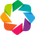

In [2]:
import holoviews as hv
hv.extension('bokeh')

In [3]:
import holoviews
holoviews.__version__

'1.17.1'

In [4]:
import bokeh
bokeh.__version__

'3.2.2'

# crpss species

In [8]:
def transfer_annotations(sm,reference_id=None, keys=[],num_iters=5, inplace = True):
    """ Transfer annotations across species using label propagation along the combined manifold.
    
    Parameters
    ----------
    sm - SAMAP object
    
    reference_id - str, optional, default None
        The species ID of the reference species from which the annotations will be transferred.
        
    keys - str or list, optional, default []
        The `obs` key or list of keys corresponding to the labels to be propagated.
        If passed an empty list, all keys in the reference species' `obs` dataframe
        will be propagated.
        
    num_iters - int, optional, default 5
        The number of steps to run the diffusion propagation.
        
    inplace - bool, optional, default True
        If True, deposit propagated labels in the target species (`sm.sams['hu']`) `obs`
        DataFrame. Otherwise, just return the soft-membership DataFrame.
        
    Returns
    -------
    A Pandas DataFrame with soft membership scores for each cluster in each cell.
    
    """
    stitched = sm.samap
    NNM = stitched.adata.obsp['connectivities'].copy()
    NNM = NNM.multiply(1/NNM.sum(1).A).tocsr()

    if type(keys) is str:
        keys = [keys]
    elif len(keys) == 0:
        try:
            keys = list(sm.sams[reference_id].adata.obs.keys())
        except KeyError:
            raise ValueError(f'`reference` must be one of {sm.ids}.')

    for key in keys:
        samref = sm.sams[reference_id]
        ANN = stitched.adata.obs
        ANNr = samref.adata.obs
        cl = ANN[reference_id+'_'+key].values.astype('object').astype('str')
        clr = ANNr[key].values.astype('object')
        cl[np.invert(np.in1d(cl,clr))]=''
        clu,clui = np.unique(cl,return_inverse=True)
        P = np.zeros((NNM.shape[0],clu.size))
        Pmask = np.ones((NNM.shape[0],clu.size))
        P[np.arange(clui.size),clui]=1.0
        Pmask[stitched.adata.obs['species']==reference_id]=0

        Pmask=Pmask[:,1:]
        P=P[:,1:]
        Pinit = P.copy()

        for j in range(num_iters):
            P_new = NNM.dot(P)
            if np.max(np.abs(P_new - P)) < 5e-3:
                P = P_new
                s=P.sum(1)[:,None]
                s[s==0]=1
                P = P/s
                break
            else:
                P = P_new
                s=P.sum(1)[:,None]
                s[s==0]=1
                P = P/s
            P = P * Pmask + Pinit

        uncertainty = 1-P.max(1)
        labels = clu[1:][np.argmax(P,axis=1)]
        labels[uncertainty==1.0]='NAN'
        uncertainty[uncertainty>=uncertainty.max()*0.99] = 1
        if inplace:
            stitched.adata.obs[key+'_transfer'] = pd.Series(labels,index = stitched.adata.obs_names)
            stitched.adata.obs[key+'_uncertainty'] = pd.Series(uncertainty,index=stitched.adata.obs_names)

        res = pd.DataFrame(data=P,index=stitched.adata.obs_names,columns=clu[1:])
        res['labels'] = labels
        return res


In [9]:
fn1 = '/DATA/User/hemingmin/AS/merge7/results/15_​cross_species/0_data/human_ref.h5ad'
fn2='/DATA/User/hemingmin/AS/merge7/results/15_​cross_species/0_data/mouse_ref.h5ad'
filenames = {'hu':fn1,'mm':fn2}


In [10]:
sm = SAMAP(
        filenames,
        f_maps = '/DATA/User/liqian7/pienapple/15human_fn/hfbq/03.samap/maps/',
        save_processed=True #if False, do not save the processed results to `*_pr.h5ad`
    )

Processing data hu from:
/DATA/User/hemingmin/AS/merge7/results/15_​cross_species/0_data/human_ref.h5ad
RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.9060695267146073
Computing the UMAP embedding...


/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Elapsed time: 47.082984924316406 seconds
Not updating the manifold...
Processing data mm from:
/DATA/User/hemingmin/AS/merge7/results/15_​cross_species/0_data/mouse_ref.h5ad
RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.7757471824147539
Iteration: 2, Convergence: 0.037124619088666155
Iteration: 3, Convergence: 0.011715479784147862
Computing the UMAP embedding...


/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Elapsed time: 124.94301867485046 seconds
Not updating the manifold...
19245 `hu` gene symbols match between the datasets and the BLAST graph.
18106 `mm` gene symbols match between the datasets and the BLAST graph.


In [25]:
import pickle
pickle.dump(sm,open('./human_v1/result.pkl','wb'))

In [31]:
sm=pickle.load(open('./human_v1/result.pkl','rb'))

In [32]:
sm

In [33]:
sm.run(pairwise=True)
samap = sm.samap # SAM object with three species stitched together

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 57.3732705116272
Correcting data with means. 44.297268867492676
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mm...
Indegree coarsening
0/4 (0, 60927)
1/4 (20000, 60927)
2/4 (40000, 60927)
3/4 (60000, 60927)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
Iteration 1 complete.
Alignment scores:
          hu       mm
hu  0.000000  0.67766
mm  0.564149  0.00000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 45.454004526138306
Correcting data with means. 47.988877296447754
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mm...
Indegree coarsening
0/4 (0, 60927)
1/4 (20000, 60927)
2/4 (40000, 60927)
3/4 (60000, 60927)
Rescaling edge weights by expression correlati

In [37]:
table=transfer_annotations(sm,reference_id='mm',keys='new_celltype_level2')

In [50]:
table.to_csv('./human_v1/annotation.csv')

In [51]:
table=transfer_annotations(sm,reference_id='mm',keys='celltype_level1')

IOStream.flush timed out


In [52]:
table.to_csv('./human_v1/anotation_celltype_level1.csv')

In [53]:
meta=pd.read_csv('./human_v1/human_ref_metadata.csv',index_col=0)
sm.sams['hu'].adata.obs['celltype_new']=meta['celltype_v2']

In [54]:
keys = {'hu':'celltype_new','mm':'celltype_level1'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)

In [57]:
keys = {'hu':'celltype_new','mm':'celltype_level1'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)
MappingTable.to_csv('./human_v1/MappingTable_HUcelltype_new_MMcelltype_level1.csv')
MappingTable.to_csv('./human_v1/D_HUcelltype_new_MMcelltype_level.csv')

In [58]:
keys = {'hu':'celltype_new','mm':'new_celltype_level2'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)
MappingTable.to_csv('./human_v1/MappingTable_HUcelltype_new_MMcelltype_level2.csv')
MappingTable.to_csv('./human_v1/D_HUcelltype_new_MMcelltype_level2.csv')

In [59]:
keys = {'hu':'leiden_clusters','mm':'celltype_level2'}
D,MappingTable = get_mapping_scores(sm,keys,n_top = 0)
# D- table of highest mapping scores for cell types 
# A - pairwise table of mapping scores between cell types across species
MappingTable.to_csv('MappingTable_HUleiden_clusters_MMcelltype_level2.csv')
MappingTable.to_csv('D_HUleiden_clusters_MMcelltype_level2.csv')

In [61]:
import scanpy as sc
import copy
adata=copy.copy(sm.samap.adata)

In [62]:
adata.write("./human_v1/result.h5ad")

# plot umap

In [2]:
from matplotlib.pyplot import rc_context
import matplotlib as mpl
import matplotlib.pyplot as plt

In [28]:
adata=sc.read_h5ad('../15_​cross_species/human_v1/result.h5ad')
adata

AnnData object with n_obs × n_vars = 60927 × 55535
    obs: 'hu_sample_name', 'hu_type', 'hu_celltype', 'hu_cell_type', 'hu_leiden_clusters', 'mm_seq_folder', 'mm_sample', 'mm_type', 'mm_batch', 'mm_Phase', 'mm_celltype_ref_GSE155513', 'mm_celltype_ref_GSE131776', 'mm_celltype_level1', 'mm_celltype_level2', 'mm_new_celltype_level2', 'mm_leiden_clusters', 'batch', 'species', 'new_celltype_level2_transfer', 'new_celltype_level2_uncertainty', 'celltype_level1_transfer', 'celltype_level1_uncertainty', 'celltype_new;celltype_level1_mapping_scores', 'celltype_new;new_celltype_level2_mapping_scores', 'leiden_clusters;celltype_level2_mapping_scores', 'lisi_samap', 'labels'
    uns: 'gnnm_corr', 'homology_gene_names_dict', 'mapping_K', 'neighbors', 'umap', 'species_colors'
    obsm: 'X_umap'
    layers: 'X_disp'
    obsp: 'connectivities'
    varp: 'homology_graph', 'homology_graph_reweighted'

In [90]:
color_dist_new={'mSMCs-1':'#7743DB', 
    'Contractile SMCs':'#1f78b4',
    'ECs':'#238b45', 
    'Col15a1 FBs':'#C2A68C',
    'DCs':'#B7A3E3',
    'Pre_modulated_SMCs':'#4D77FF',
    'Tcell':'#ce1256', 
    'Inflammatory ECs':'#00FF9C',
    'SMC-like ECs':'#06D001', 
    'Inflammatory macro.':'#df65b0', 
    'mSMCs-2':'#A1CFFA', 
    'Spp1+Trem2 macro.':'#FF70AB', 
    'Pi16 FBs': '#8b4a4b',
    'Pericytes':'#3330E4', 
    'SMC-like macro.':'#F9E400', 
    "hu":'lightgrey',
    "mm":'lightgrey'}


/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


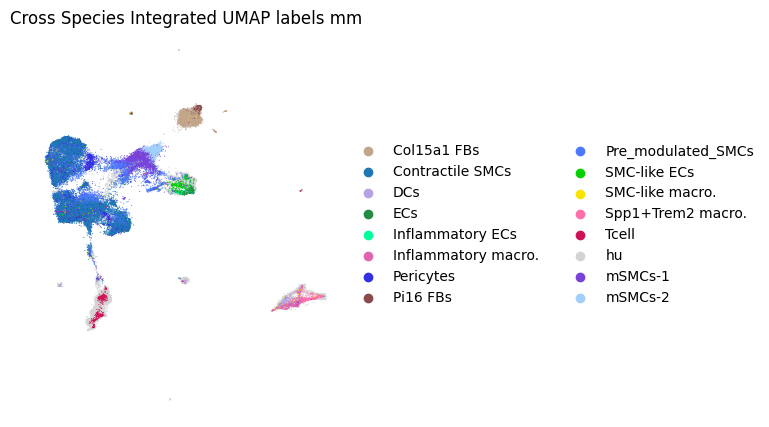

In [169]:

fig, ax = plt.subplots(figsize=(4, 5))
sc.pl.umap(adata, color=['choose_type'], 
           size=2.5,
             alpha=0.9, 
           add_outline=False,
           # legend_fontsize=10, 
           # legend_fontoutline=1, 
           legend_loc="right margin",
           ax=ax,
           palette= color_dist_new,
           frameon=False,
           title='Cross Species Integrated UMAP labels mm',
          show=True,save=f"cross_intergrated_umap_labels_mm_new2.5_f.pdf")

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


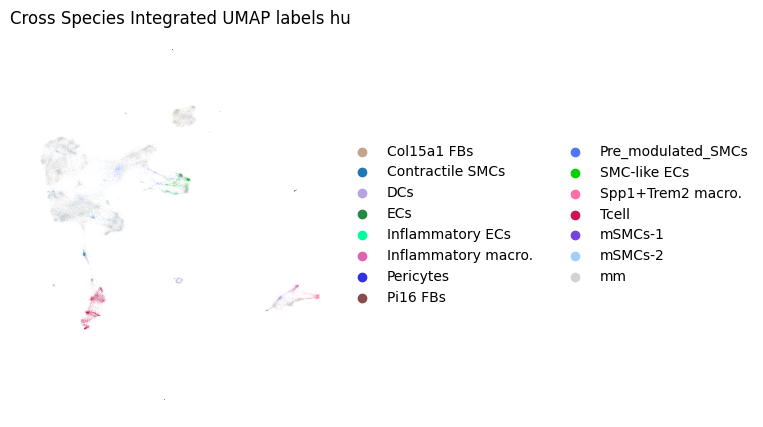

In [194]:
fig, ax = plt.subplots(figsize=(4, 5))
adata.obs['choose_type'] = adata.obs['labels'].astype(str)
adata.obs.loc[adata.obs['species'] == 'mm', 'choose_type'] = 'mm'

sc.pl.umap(adata, color=['choose_type'], 
           size=0.1,
             alpha=0.9, 
           add_outline=False,
           # legend_fontsize=10, 
           # legend_fontoutline=1, 
           legend_loc="right margin",
           ax=ax,
           palette= color_dist_new,
           frameon=False,
           title='Cross Species Integrated UMAP labels hu',
          show=True,save=f"cross_intergrated_umap_labels_hu_new0.1_f.pdf")

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_t

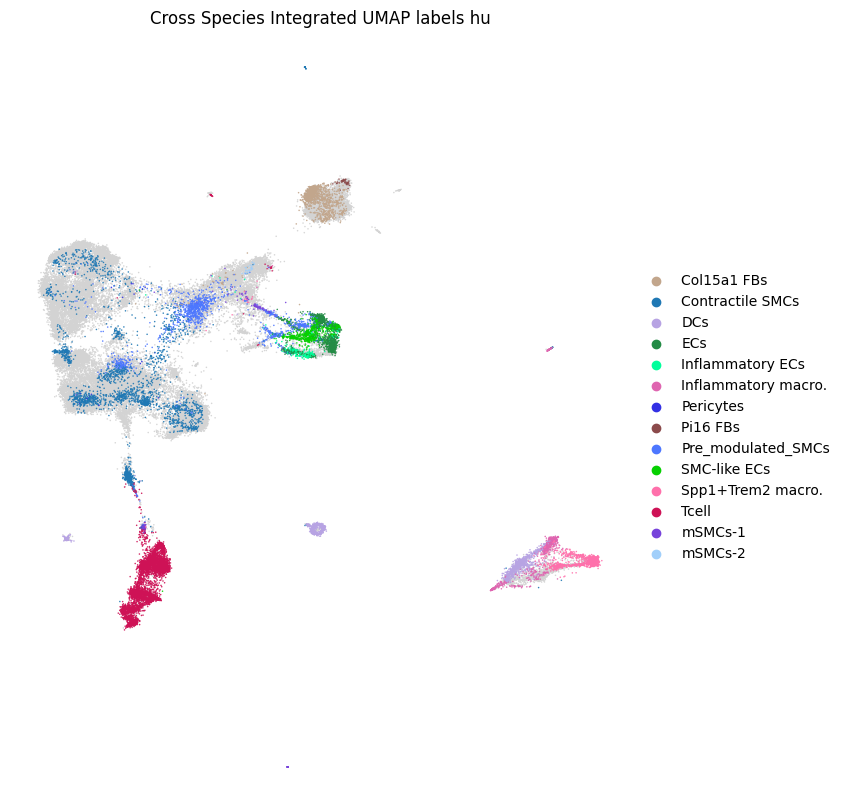

In [208]:

adata.obs['choose_type'] = adata_filtered2.obs['labels'].astype(str)
adata.obs.loc[adata_filtered2.obs['species'] == 'mm', 'choose_type'] = 'mm'

fig, ax = plt.subplots(figsize=(8, 10))
mm_mask = adata.obs['choose_type'] == 'mm'
sc.pl.umap(
    adata[mm_mask],
    color=['choose_type'],
    size=5,
    alpha=0.9,
    add_outline=False,
    # legend_fontsize=10,
    # legend_fontoutline=1,
    legend_loc="none",              # 不显示图例
    ax=ax,
    palette={'mm': 'lightgray'},         # 强制 'mm' 为灰色
    frameon=False,
    show=False,
    save=False
)

# 然后绘制其他类型的点
other_mask = adata.obs['choose_type'] != 'mm'
sc.pl.umap(
    adata[other_mask],
    color=['choose_type'],
    size=5,
    alpha=0.9,
    add_outline=False,
    legend_loc="right margin",
    ax=ax,
    palette={k: v for k, v in color_dist_new.items() if k != 'mm'},
    frameon=False,
    title='Cross Species Integrated UMAP labels hu',
    show=False,
    save=False
)

# 如果需要保存图形
plt.savefig("cross_intergrated_umap_labels_hu_new5_f.pdf", dpi=600, bbox_inches='tight')

# 显示图形
plt.show()

In [ ]:
adata.obs['choose_type'] = adata_filtered2.obs['labels'].astype(str)
adata.obs.loc[adata_filtered2.obs['species'] == 'hu', 'choose_type'] = 'hu'

fig, ax = plt.subplots(figsize=(8, 10))
mm_mask = adata.obs['choose_type'] == 'hu'
sc.pl.umap(
    adata[mm_mask],
    color=['choose_type'],
    size=5,
    alpha=0.9,
    add_outline=False,
    # legend_fontsize=10,
    # legend_fontoutline=1,
    legend_loc="none",              # 不显示图例
    ax=ax,
    palette={'hu': 'lightgray'},         # 强制 'mm' 为灰色
    frameon=False,
    show=False,
    save=False
)

# 然后绘制其他类型的点
other_mask = adata.obs['choose_type'] != 'hu'
sc.pl.umap(
    adata[other_mask],
    color=['choose_type'],
    size=5,
    alpha=0.9,
    add_outline=False,
    legend_loc="right margin",
    ax=ax,
    palette={k: v for k, v in color_dist_new.items() if k != 'hu'},
    frameon=False,
    title='Cross Species Integrated UMAP labels mm',
    show=False,
    save=False
)

# 如果需要保存图形
plt.savefig("cross_intergrated_umap_labels_mm_new5_f.pdf", dpi=600, bbox_inches='tight')

# 显示图形
plt.show()

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_t

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


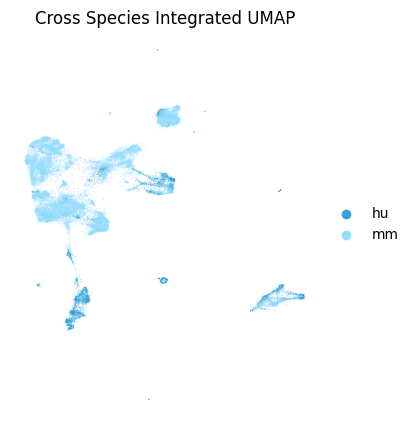

In [172]:
color_dist2={
"hu":'#39A2DB',
"mm":'#93DEFF'
}
fig, ax = plt.subplots(figsize=(4, 5))
# with plt.rc_context({'axes.facecolor':'white','figure.figsize': [4, 4]}):
sc.pl.umap(adata, color=['species'], 
           size=0.5,
             alpha=0.9, 
           add_outline=False,
           # legend_fontsize=10, 
           # legend_fontoutline=1, 
           legend_loc="right margin",
           ax=ax,
           palette= color_dist2,
           frameon=False,
           title='Cross Species Integrated UMAP',
          show=True,save=f"cross_intergrated_umap_species2.pdf")

In [4]:
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.backends.backend_pdf import PdfPages
import os
import seaborn as sns

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


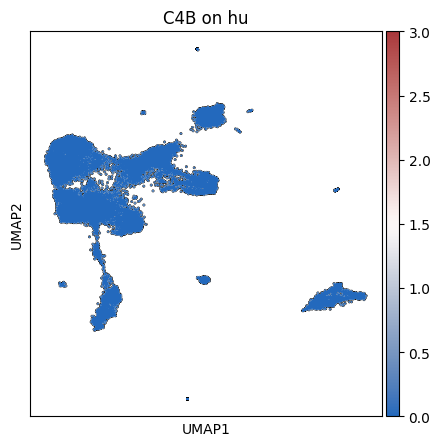

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


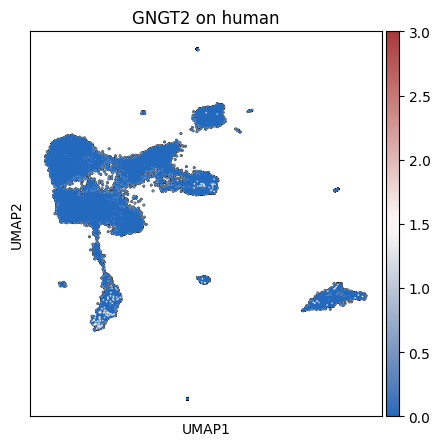

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


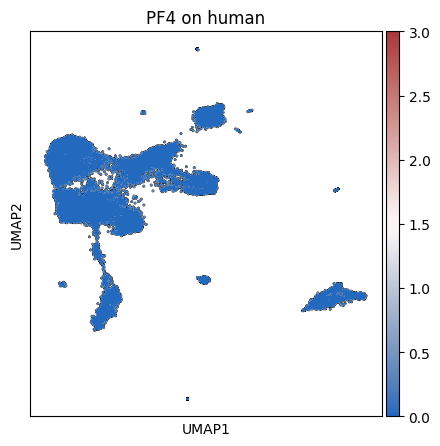

In [6]:
adata=adata_filtered2
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='hu_C4B', palette='cividis',
        vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
         title='C4B on hu', show=True,save=f"hu_C4B_on_human.pdf")
# 绘制Mmp9在UMAP上的表达
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='hu_GNGT2', palette='cividis',
            vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
            title='GNGT2 on human', show=True,save=f"hu_GNGT2_on_human.pdf")

fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='hu_PF4', palette='cividis',
            vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
            title='PF4 on human', show=True,save=f"hu_PF4_on_human.pdf")

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


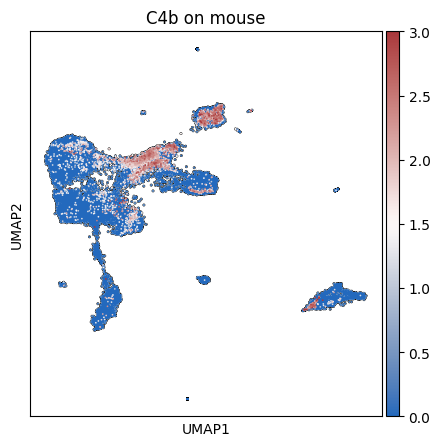

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


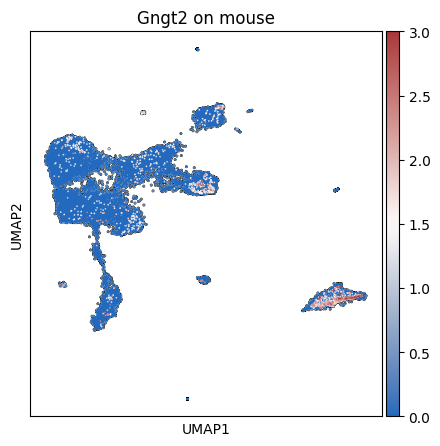

In [176]:
adata=adata_filtered2
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='mm_C4b', palette='cividis',
        vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
         title='C4b on mouse', show=True,save=f"mm_C4b_on_mouse.pdf")
# 绘制Mmp9在UMAP上的表达
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='mm_Gngt2', palette='cividis',
            vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
            title='Gngt2 on mouse', show=True,save=f"mm_Gngt2_on_mouse.pdf")

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


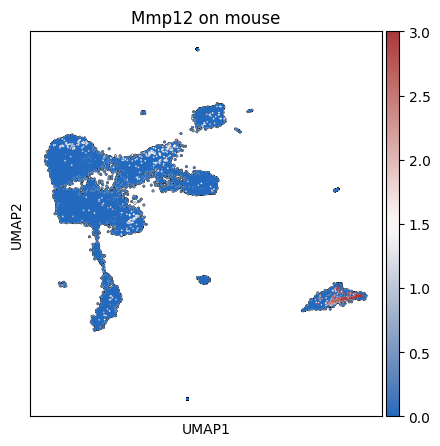

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


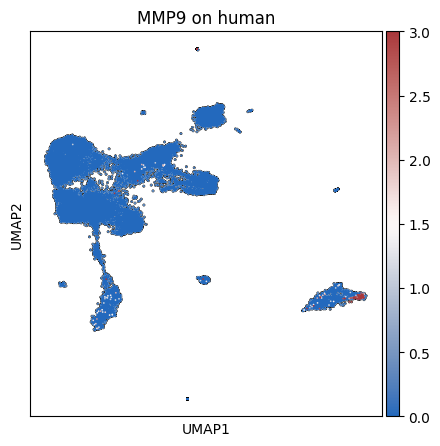

In [178]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='mm_Mmp12', palette='cividis',
        vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
         title='Mmp12 on mouse', show=True,save=f"mm_Mmp12_on_mouse.pdf")
# 绘制Mmp9在UMAP上的表达
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='hu_MMP9', palette='cividis',
            vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
            title='MMP9 on human', show=True,save=f"hu_MMP9_on_human.pdf")

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


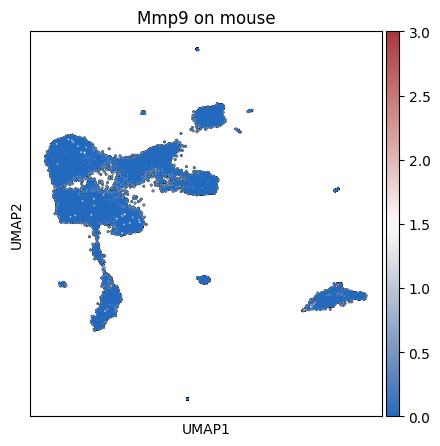

/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1208: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/liqian7/tools/Anaconda3/envs/SAMap/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


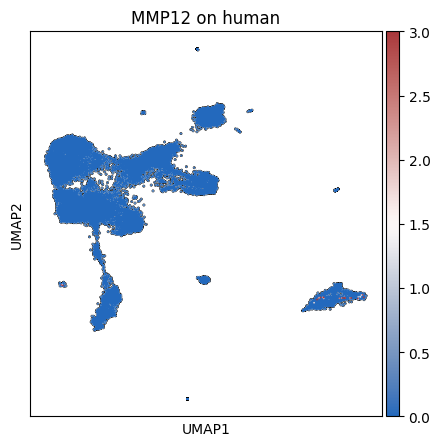

In [179]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='mm_Mmp9', palette='cividis',
        vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
         title='Mmp9 on mouse', show=True,save=f"mm_Mmp9_on_mouse.pdf")
# 绘制Mmp9在UMAP上的表达
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color='hu_MMP12', palette='cividis',
            vmax=3,vmin=0,  size=6,
             alpha=1, add_outline=True,
           ax=ax, 
           color_map= sns.color_palette("vlag", as_cmap=True),
            title='MMP12 on human', show=True,save=f"hu_MMP12_on_human.pdf")

# plot sankey

In [5]:
import pandas as pd
import plotly.graph_objects as go
import kaleido  # 用于导出静态图片
import plotly.io as pio

<>:24: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?

<>:25: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?

<>:24: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?

<>:25: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?

/tmp/ipykernel_522378/260517473.py:24: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?

/tmp/ipykernel_522378/260517473.py:25: SyntaxWarning:

'int' object is not subscriptable; perhaps you missed a comma?



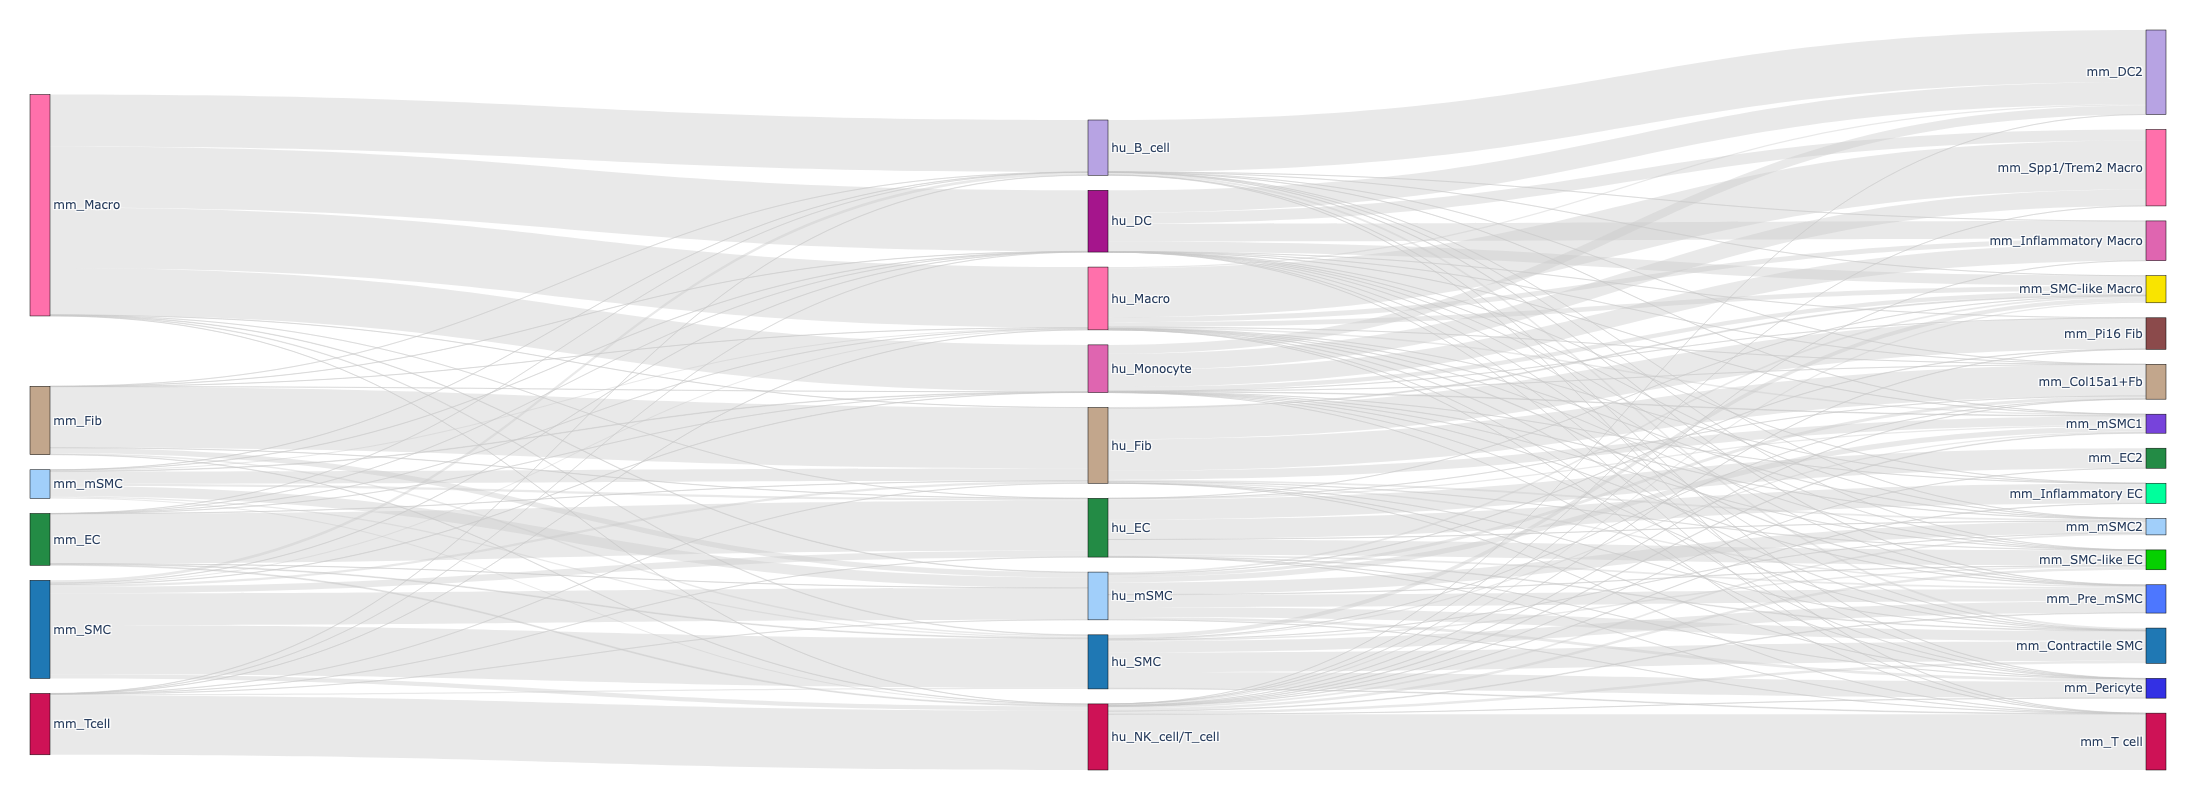

In [22]:
import pandas as pd
import plotly.graph_objects as go

# 1. 加载数据
df_level1 = pd.read_csv('./sankey_level1.txt', sep='\t', index_col=0)
df_level2 = pd.read_csv('./sankey_level2.txt', sep='\t', index_col=0)

# 2. 提取节点
mm_level1_nodes = [name for name in df_level1.index if name.startswith('mm_')]
hu_nodes = [name for name in df_level1.columns if name.startswith('hu_')]
mm_level2_nodes = [name for name in df_level2.columns if name.startswith('mm_')]

all_node_names = mm_level1_nodes + hu_nodes + mm_level2_nodes
node_to_index = {name: idx for idx, name in enumerate(all_node_names)}

# 3. 构建连接关系
sources = []
targets = []
values = []

# --- 关键修改：流量标准化 ---
# 为了消除中间层的空白，我们需要确保 hu 节点的流入量 = 流出量
for hu in hu_nodes:
    in_val = df_level1[hu].sum() if hu in df_level1.columns else 0 [cite: 1]
    out_val = df_level2.loc[hu].sum() if hu in df_level2.index else 0 [cite: 2]
    
    # 如果流入流出不相等，通过缩放比例使它们在视觉上完全匹配
    scale = in_val / out_val if out_val > 0 else 1

    # Level 1 -> hu
    for mm1 in mm_level1_nodes:
        val = df_level1.loc[mm1, hu]
        if val > 0:
            sources.append(node_to_index[mm1])
            targets.append(node_to_index[hu])
            values.append(val)

    # hu -> Level 2 (乘以缩放系数消除空白)
    for mm2 in mm_level2_nodes:
        val = df_level2.loc[hu, mm2]
        if val > 0:
            sources.append(node_to_index[hu])
            targets.append(node_to_index[mm2])
            values.append(val * scale) # 强制流出等于流入 

# 4. 颜色与布局设置
color_dist = {
    # Level1 mm nodes
    "mm_Fib": '#C2A68C',
    "mm_SMC": '#1f78b4',
    "mm_Macro": '#FF70AB',
    "mm_mSMC": '#A1CFFA',
    "mm_Tcell": '#ce1256',
    "mm_EC": '#238b45',
    
    # hu nodes
    "hu_B_cell": '#B7A3E3',
    "hu_DC": '#A5158C',
    "hu_EC": '#238b45',
    "hu_Fib": '#C2A68C',
    "hu_Macro": '#FF70AB',
    "hu_Monocyte": '#df65b0',
    "hu_NK_cell/T_cell": '#ce1256',
    "hu_SMC": '#1f78b4',
    "hu_mSMC": '#A1CFFA',
    "hu_plasma cell": '#F0E685',
    
    # Level2 mm nodes

    "mm_Col15a1+Fb": '#C2A68C',
    "mm_Contractile SMC": '#1f78b4',
    "mm_DC2": '#B7A3E3',
    "mm_Inflammatory Macro": '#df65b0',
    "mm_Pericyte": '#3330E4',
    "mm_Pre_mSMC": '#4D77FF',
    "mm_SMC-like EC": '#06D001',
    "mm_SMC-like Macro": '#F9E400',
    "mm_T cell": '#ce1256',
    "mm_mSMC1": '#7743DB',
    "mm_mSMC2": '#A1CFFA',
    "mm_Inflammatory EC": '#00FF9C',
    "mm_Pi16 Fib": '#8b4a4b',
    "mm_Spp1/Trem2 Macro": '#FF70AB',
    "mm_EC2": '#238b45'
}

node_colors = [color_dist.get(name, '#CCCCCC') for name in all_node_names]

# 5. 绘图
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed", # 强制固定排列，不允许自动跳跃
    node=dict(
        pad=15, # 节点间的间距
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_node_names,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color='rgba(200, 200, 200, 0.4)'
    )
)])

# fig.update_layout(height=800, width=600, font_size=12)
fig.update_layout(
    # title="三级桑基图: mm_level1 → hu → mm_level2",
    font_size=12,
    height=800,
    width=600,
    margin=dict(l=30, r=30, t=30, b=30)
)

fig.write_html("./sankey_no_gaps.html")
fig.show()

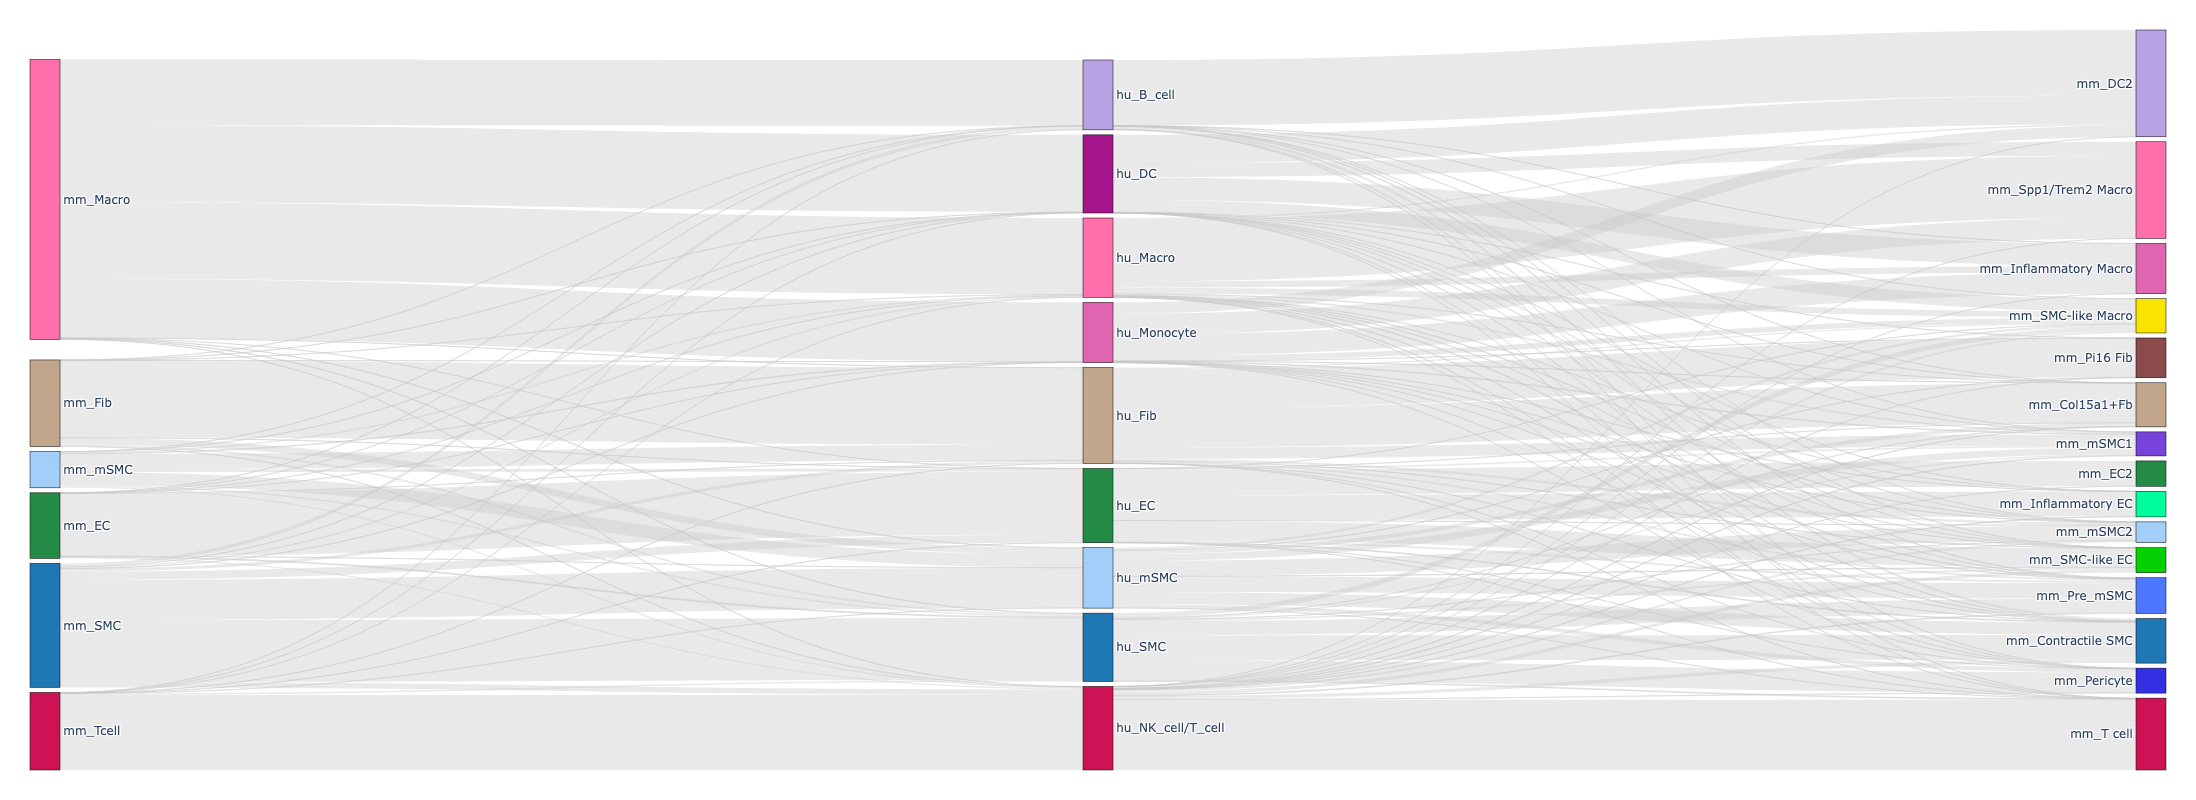

In [4]:
import pandas as pd
import plotly.graph_objects as go

# 1. 加载数据
df_level1 = pd.read_csv('./sankey_level1.txt', sep='\t', index_col=0)
df_level2 = pd.read_csv('./sankey_level2.txt', sep='\t', index_col=0)

# 2. 提取并清理节点数据
mm_level1_nodes = [name for name in df_level1.index if name.startswith('mm_')]
hu_nodes = [name for name in df_level1.columns if name.startswith('hu_')]
mm_level2_nodes = [name for name in df_level2.columns if name.startswith('mm_')]

# 提取矩阵并过滤非相关项
mat1 = df_level1.loc[mm_level1_nodes, hu_nodes].copy()
mat2 = df_level2.loc[hu_nodes, mm_level2_nodes].copy()

# =============================================
# 3. 核心优化：实现每一级等高 (流量归一化)
# =============================================
# A. 使 Level 2 的总权重等于 Level 1
s1_total = mat1.values.sum()
s2_total = mat2.values.sum()
if s2_total > 0:
    mat2 = mat2 * (s1_total / s2_total)

# B. 针对每个 hu 节点实现“流入=流出”，消除节点内空白
for hu in hu_nodes:
    inflow = mat1[hu].sum()   # 该 hu 节点的流入总和
    outflow = mat2.loc[hu].sum() # 该 hu 节点的流出总和
    
    if outflow > 0:
        # 缩放该节点发出的所有连线，使其总和等于流入量
        mat2.loc[hu] = mat2.loc[hu] * (inflow / outflow)

# =============================================
# 4. 构建 Plotly 绘图数据
# =============================================
all_node_names = mm_level1_nodes + hu_nodes + mm_level2_nodes
node_to_index = {name: idx for idx, name in enumerate(all_node_names)}

sources, targets, values = [], [], []

# 添加第一级连线 (mm1 -> hu)
for mm1 in mm_level1_nodes:
    for hu in hu_nodes:
        val = mat1.loc[mm1, hu]
        if val > 0:
            sources.append(node_to_index[mm1])
            targets.append(node_to_index[hu])
            values.append(val)

# 添加第二级连线 (hu -> mm2)
for hu in hu_nodes:
    for mm2 in mm_level2_nodes:
        val = mat2.loc[hu, mm2]
        if val > 0:
            sources.append(node_to_index[hu])
            targets.append(node_to_index[mm2])
            values.append(val)

# 颜色映射
color_dist = {
    "mm_Fib": '#C2A68C', "mm_SMC": '#1f78b4', "mm_Macro": '#FF70AB',
    "mm_mSMC": '#A1CFFA', "mm_Tcell": '#ce1256', "mm_EC": '#238b45',
    "hu_B_cell": '#B7A3E3', "hu_DC": '#A5158C', "hu_EC": '#238b45',
    "hu_Fib": '#C2A68C', "hu_Macro": '#FF70AB', "hu_Monocyte": '#df65b0',
    "hu_NK_cell/T_cell": '#ce1256', "hu_SMC": '#1f78b4', "hu_mSMC": '#A1CFFA',
    "mm_Col15a1+Fb": '#C2A68C', "mm_Contractile SMC": '#1f78b4', "mm_DC2": '#B7A3E3',
    "mm_Inflammatory Macro": '#df65b0', "mm_Pericyte": '#3330E4', "mm_Pre_mSMC": '#4D77FF',
    "mm_SMC-like EC": '#06D001', "mm_SMC-like Macro": '#F9E400', "mm_T cell": '#ce1256',
    "mm_mSMC1": '#7743DB', "mm_mSMC2": '#A1CFFA', "mm_Inflammatory EC": '#00FF9C',
    "mm_Pi16 Fib": '#8b4a4b', "mm_Spp1/Trem2 Macro": '#FF70AB', "mm_EC2": '#238b45'
}
node_colors = [color_dist.get(name, '#CCCCCC') for name in all_node_names]

# 5. 绘图
fig = go.Figure(data=[go.Sankey(
    # arrangement="fixed",
    node=dict(
        pad=5,           # 关键：消除柱子之间的垂直间隙
        thickness=30,     # 柱子宽度
        line=dict(color="black", width=0.5),
        label=all_node_names,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color='rgba(200, 200, 200, 0.4)'
    )
)])


fig.update_layout(
    # title="三级桑基图: mm_level1 → hu → mm_level2",
    font_size=12,
    height=800,
    width=600,
    margin=dict(l=30, r=30, t=30, b=30)
)

# fig.write_html("./sankey_perfect_alignment_no_gap.html")
fig.write_html("./sankey_perfect_alignment.html")
fig.show()